# Traffic Sign Classification — ResNet18 Transfer Learning (PyTorch)

**Dataset:** Australian Traffic Signs — Google Drive  
**Model:** ResNet18 pre-trained on ImageNet — Transfer Learning  
**Framework:** PyTorch + torchvision  
**Approach:** Feature Extraction → Fine-Tuning (Two-phase training)  

---
### Pipeline Steps
```
Step 1  → Mount Google Drive & copy dataset to local SSD
Step 2  → Import libraries & global config
Step 3  → Dataset analysis & exploration
Step 4  → Data visualizations
Step 5  → Preprocessing & direction-aware augmentation (PyTorch)
Step 6  → ResNet18 model setup (Transfer Learning)
Step 7  → Phase 1: Feature Extraction (frozen backbone)
Step 8  → Phase 2: Fine-Tuning (unfrozen backbone)
Step 9  → Training visualizations
Step 10 → Evaluation & confusion matrix
Step 11 → Prediction demo
Step 12 → Save & download model
```

### Two-Phase Transfer Learning Strategy
```
Phase 1 — Feature Extraction (10-15 epochs)
  ResNet18 backbone : FROZEN  (ImageNet weights preserved)
  Classifier head   : TRAINED (learns traffic sign features)
  Learning rate     : 0.001
  Purpose           : Quickly train the new head without
                      destroying pre-trained features

Phase 2 — Fine-Tuning (15-25 epochs)
  ResNet18 backbone : UNFROZEN (all weights updated)
  Classifier head   : TRAINED
  Learning rate     : 0.00001  (very small — careful updates)
  Purpose           : Adapt ImageNet features to traffic signs
```

---
## Step 1: Mount Google Drive & Copy Dataset to Local SSD

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted')

Mounted at /content/drive
Google Drive mounted


In [ ]:
import shutil, os
from pathlib import Path

# ── Source: your dataset on Google Drive
# Update this path if your folder structure is different
DRIVE_DATASET = '/content/drive/MyDrive/Traffic CNN/Traffic Data'

# ── Destination: Colab local SSD (fast I/O — critical for training speed)
# Reading from Google Drive during training = 19s/step (very slow)
# Reading from local SSD = 0.2s/step (fast)
LOCAL_DATASET = '/content/traffic_data'

if not Path(LOCAL_DATASET).exists():
    print('Copying dataset from Drive to local SSD...')
    print('This takes 3-5 minutes but training will be much faster.')
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
    print('Copy complete!')
else:
    print('Dataset already on local SSD — skipping copy.')

# Verify
classes = sorted([d.name for d in Path(LOCAL_DATASET).iterdir() if d.is_dir()])
print(f'Classes found: {len(classes)}')
for c in classes:
    n = len(list((Path(LOCAL_DATASET)/c).rglob('*')))
    print(f'  {c:<25} {n} files')

Copying dataset from Drive to local SSD...
This takes 3-5 minutes but training will be much faster.
Copy complete!
Classes found: 15
  exitleft                  302 files
  exitright                 6126 files
  giveway                   4889 files
  noentry                   3681 files
  noovertaking              769 files
  oneway                    2701 files
  pedestrian                1065 files
  roundabout                1211 files
  speedlimit100             2880 files
  speedlimit20              1099 files
  speedlimit60              3056 files
  stop                      2615 files
  trafficsignalahead        1629 files
  turnleft                  1384 files
  turnright                 804 files


---
## Step 2: Import Libraries & Global Config

In [ ]:
import os, random, json, copy
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# ── PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── torchvision — provides ResNet18 and image transforms
import torchvision
import torchvision.transforms as transforms
from torchvision import models

# ── scikit-learn for evaluation
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# ── Hyperparameters
IMG_SIZE         = 224    # ResNet18 recommended input size
BATCH_SIZE       = 64
PHASE1_EPOCHS    = 15     # Feature extraction phase
PHASE2_EPOCHS    = 25     # Fine-tuning phase
PHASE1_LR        = 0.001  # Higher LR for new classifier head
PHASE2_LR        = 1e-5   # Very small LR for fine-tuning
VAL_SPLIT        = 0.15
TEST_SPLIT       = 0.10
NUM_WORKERS      = 2      # Parallel data loading workers

MODEL_DIR = '/content/models'
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Device: use GPU if available, else CPU
# PyTorch requires explicitly moving tensors and models to the device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — training will be very slow. Enable GPU in Runtime settings.')

print(f'\nConfig: IMG={IMG_SIZE} | BATCH={BATCH_SIZE} | Phase1={PHASE1_EPOCHS}ep | Phase2={PHASE2_EPOCHS}ep')

Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB

Config: IMG=224 | BATCH=64 | Phase1=15ep | Phase2=25ep


---
## Step 3: Dataset Analysis & Exploration

In [ ]:
DATASET_ROOT = Path(LOCAL_DATASET)
VALID_EXT    = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}

image_paths, labels = [], []
for class_dir in sorted(DATASET_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue
    class_name = class_dir.name
    imgs = [str(p) for p in class_dir.rglob('*') if p.suffix.lower() in VALID_EXT]
    image_paths.extend(imgs)
    labels.extend([class_name] * len(imgs))

df           = pd.DataFrame({'filepath': image_paths, 'label': labels})
CLASS_NAMES  = sorted(df['label'].unique().tolist())
NUM_CLASSES  = len(CLASS_NAMES)
class_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}
df['label_idx'] = df['label'].map(class_to_idx)

# ── Directional classes — arrow direction must be preserved
# Flipping these changes their meaning:
#   turnright → looks like turnleft
#   exitleft  → looks like exitright
DIRECTIONAL_CLASSES = {'oneway', 'turnleft', 'turnright', 'exitleft', 'exitright'}
DIRECTIONAL_INDICES = {class_to_idx[c] for c in DIRECTIONAL_CLASSES if c in class_to_idx}

print(f'Total images  : {len(df):,}')
print(f'Total classes : {NUM_CLASSES}')
print(f'\nDirectional signs (NO flip/rotate):')
for c in sorted(DIRECTIONAL_CLASSES):
    if c in class_to_idx:
        print(f'  [{class_to_idx[c]:>2}] {c}')
print()
counts = df['label'].value_counts().sort_values(ascending=False)
for cls, cnt in counts.items():
    bar = '#' * (cnt // 200)
    print(f'  {cls:<25} {cnt:>5}  {bar}')

Total images  : 34,211
Total classes : 15

Directional signs (NO flip/rotate):
  [ 0] exitleft
  [ 1] exitright
  [ 5] oneway
  [13] turnleft
  [14] turnright

  exitright                  6126  ##############################
  giveway                    4889  ########################
  noentry                    3681  ##################
  speedlimit60               3056  ###############
  speedlimit100              2880  ##############
  oneway                     2701  #############
  stop                       2615  #############
  trafficsignalahead         1629  ########
  turnleft                   1384  ######
  roundabout                 1211  ######
  speedlimit20               1099  #####
  pedestrian                 1065  #####
  turnright                   804  ####
  noovertaking                769  ###
  exitleft                    302  #


---
## Step 4: Data Visualizations

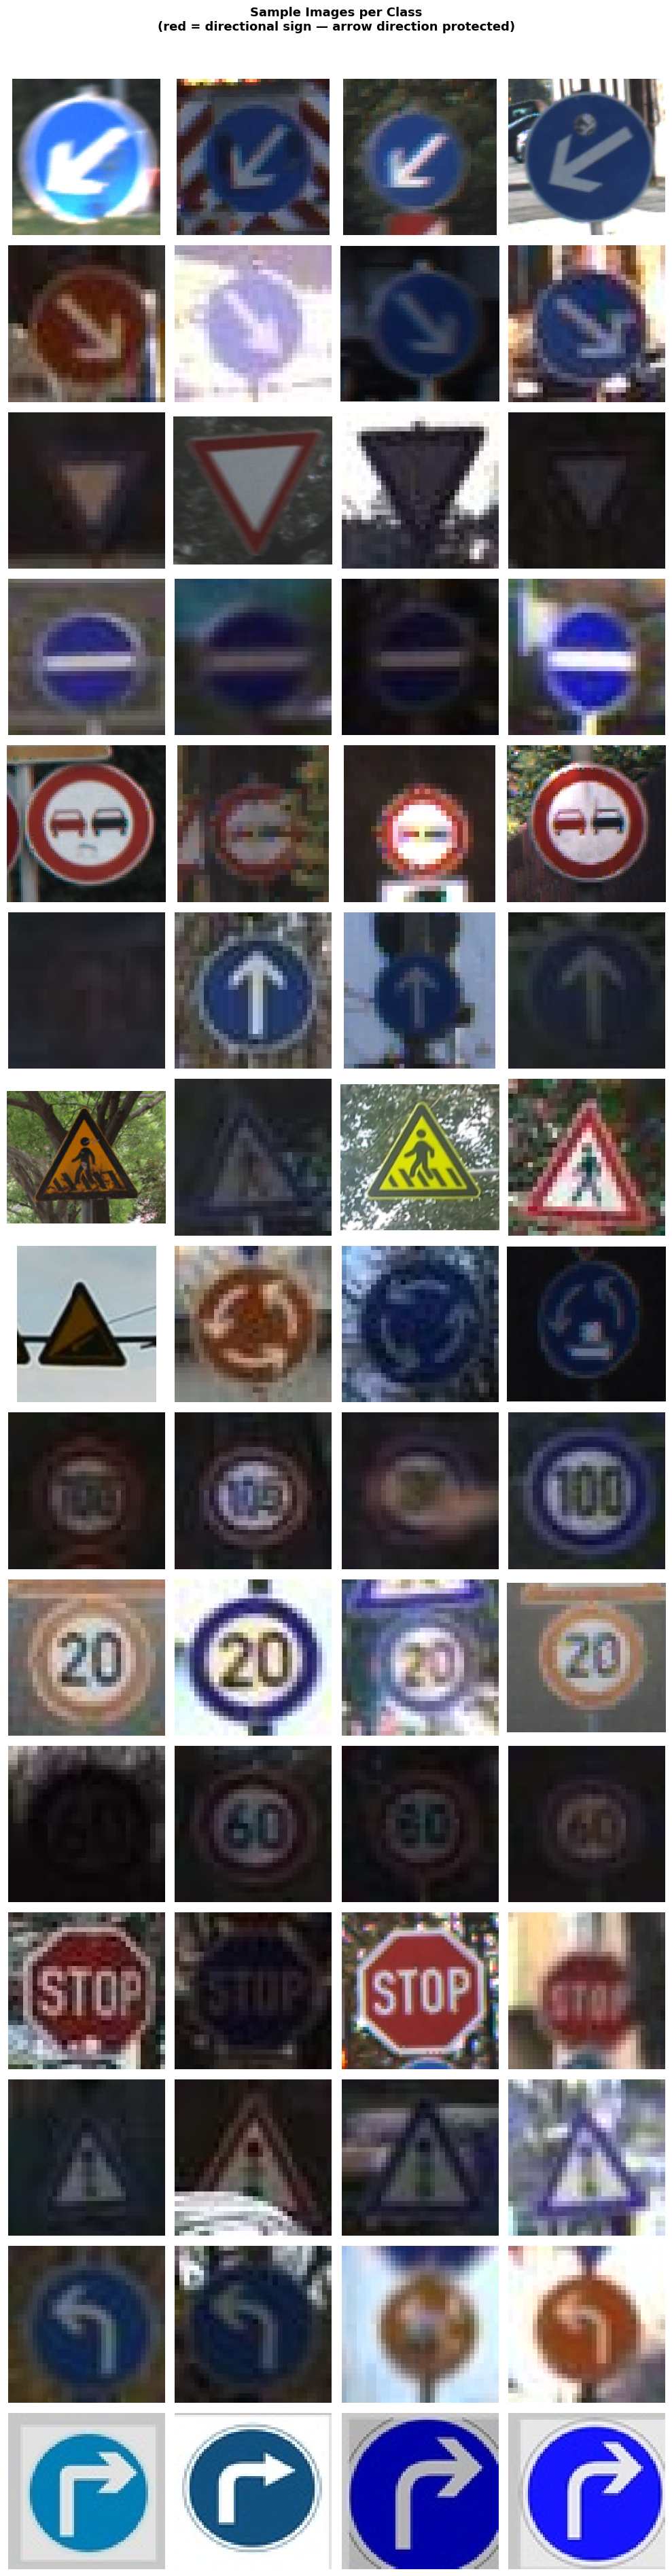

In [ ]:
# ── VIZ 2: Sample images per class
SAMPLES = 4
fig, axes = plt.subplots(NUM_CLASSES, SAMPLES,
                          figsize=(SAMPLES * 2.5, NUM_CLASSES * 2.5))
fig.suptitle('Sample Images per Class\',
             fontsize=13, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    paths = df[df['label'] == cls]['filepath'].tolist()
    picks = random.sample(paths, min(SAMPLES, len(paths)))
    for col, path in enumerate(picks):
        ax = axes[row][col]
        ax.imshow(Image.open(path).convert('RGB'))
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(
                cls, fontsize=8, fontweight='bold',
                rotation=0, labelpad=65, va='center',
                color='red' if cls in DIRECTIONAL_CLASSES else 'black'
            )

plt.tight_layout()
plt.savefig('/content/viz_sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 5: Preprocessing & Direction-Aware Augmentation (PyTorch)

PyTorch uses `transforms` instead of `tf.data` for image preprocessing.
We build **two separate transform pipelines**:
- `train_transform_directional` — NO flip, NO rotation (arrow direction preserved)
- `train_transform_normal` — full augmentation including flip and rotation

The custom `TrafficSignDataset` class applies the correct transform
based on each image's label.

In [ ]:
all_paths  = df['filepath'].tolist()
all_labels = df['label_idx'].tolist()

# Stratified split — keeps class proportions equal in every split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SPLIT, random_state=SEED, stratify=all_labels
)
val_fraction = VAL_SPLIT / (1 - TEST_SPLIT)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=val_fraction, random_state=SEED, stratify=train_val_labels
)

print(f'Train : {len(train_paths):,} images')
print(f'Val   : {len(val_paths):,} images')
print(f'Test  : {len(test_paths):,} images')

Train : 25,657 images
Val   : 5,132 images
Test  : 3,422 images


In [ ]:
# ── Class weights for imbalanced dataset
weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
# PyTorch needs weights as a FloatTensor on the same device as the model
class_weights = torch.FloatTensor(weights_array).to(DEVICE)

print('Class weights:')
for idx, w in sorted(enumerate(weights_array), key=lambda x: -x[1]):
    marker = ' [DIRECTIONAL]' if idx in DIRECTIONAL_INDICES else ''
    print(f'  [{idx:>2}] {CLASS_NAMES[idx]:<25} {w:.3f}{marker}')

Class weights:
  [ 0] exitleft                  7.535 [DIRECTIONAL]
  [ 4] noovertaking              2.964
  [14] turnright                 2.837 [DIRECTIONAL]
  [ 6] pedestrian                2.143
  [ 9] speedlimit20              2.076
  [ 7] roundabout                1.884
  [13] turnleft                  1.648 [DIRECTIONAL]
  [12] trafficsignalahead        1.400
  [11] stop                      0.872
  [ 5] oneway                    0.844 [DIRECTIONAL]
  [ 8] speedlimit100             0.792
  [10] speedlimit60              0.746
  [ 3] noentry                   0.620
  [ 2] giveway                   0.467
  [ 1] exitright                 0.372 [DIRECTIONAL]


In [ ]:
# ── ImageNet normalization values
# ResNet18 was pre-trained with these exact mean/std values
# We MUST use the same normalization so pre-trained features work correctly
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transform for DIRECTIONAL signs (training)
# NO RandomHorizontalFlip — mirrors left/right arrow
# NO RandomRotation       — tilts arrow direction
# SAFE: colour jitter, slight zoom via RandomResizedCrop
train_transform_directional = transforms.Compose([
    # RandomResizedCrop: zoom effect — simulates sign at different distances
    # scale=(0.85, 1.0) means only slight zoom — preserves sign appearance
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.ColorJitter(
        brightness=0.25,   # lighting changes
        contrast=0.25,     # camera quality
        saturation=0.20,   # colour intensity
        hue=0.05           # slight colour shift
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Transform for NON-DIRECTIONAL signs (training)
# Full augmentation — flip and rotation safe for symmetric signs
train_transform_normal = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),      # safe — symmetric signs
    transforms.RandomRotation(degrees=15),         # safe — rotation ok
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# ── Transform for VALIDATION and TEST sets
# No augmentation — just resize, center crop, normalize
# Must match the input format ResNet18 expects
val_test_transform = transforms.Compose([
    transforms.Resize(256),           # resize shorter edge to 256
    transforms.CenterCrop(IMG_SIZE),  # crop center 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Transforms ready:')
print('  train_transform_directional — NO flip, NO rotate')
print('  train_transform_normal      — full augmentation')
print('  val_test_transform          — resize + normalize only')

Transforms ready:
  train_transform_directional — NO flip, NO rotate
  train_transform_normal      — full augmentation
  val_test_transform          — resize + normalize only


In [ ]:
# ── Custom PyTorch Dataset class
#
# In PyTorch, Dataset is a class that tells the DataLoader:
#   - how many images exist  (__len__)
#   - how to load one image  (__getitem__)
#
# Our custom class applies DIFFERENT transforms based on the label —
# directional signs get direction-safe transforms, others get full augmentation

class TrafficSignDataset(Dataset):
    def __init__(self, paths, labels, directional_indices,
                 transform_directional=None, transform_normal=None):
        """
        Args:
            paths                : list of image file paths
            labels               : list of integer class labels
            directional_indices  : set of label indices that are directional
            transform_directional: transform for directional signs (no flip)
            transform_normal     : transform for non-directional signs (full)
        """
        self.paths                 = paths
        self.labels                = labels
        self.directional_indices   = directional_indices
        self.transform_directional = transform_directional
        self.transform_normal      = transform_normal

    def __len__(self):
        # Total number of images in this dataset split
        return len(self.paths)

    def __getitem__(self, idx):
        """
        Load one image and its label by index.
        Called automatically by DataLoader for each item in a batch.
        """
        # Load image from disk and convert to RGB
        image = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]

        # Apply direction-aware transform
        if label in self.directional_indices:
            # Directional sign — use safe transform (no flip, no rotate)
            if self.transform_directional:
                image = self.transform_directional(image)
        else:
            # Non-directional sign — full augmentation allowed
            if self.transform_normal:
                image = self.transform_normal(image)

        return image, label


# ── For validation and test — same transform for all classes
class TrafficSignDatasetEval(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# ── Create dataset objects
train_dataset = TrafficSignDataset(
    train_paths, train_labels,
    directional_indices   = DIRECTIONAL_INDICES,
    transform_directional = train_transform_directional,
    transform_normal      = train_transform_normal
)
val_dataset  = TrafficSignDatasetEval(val_paths,  val_labels,  val_test_transform)
test_dataset = TrafficSignDatasetEval(test_paths, test_labels, val_test_transform)

# ── Create DataLoaders
# DataLoader batches images together and loads them in parallel
# shuffle=True for training — randomize order every epoch
# pin_memory=True — speeds up CPU→GPU transfer
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Sanity check
imgs, lbls = next(iter(train_loader))
print(f'Batch shape   : {imgs.shape}  (batch x channels x H x W)')
print(f'Pixel range   : [{imgs.min():.3f}, {imgs.max():.3f}]  (normalized)')

Train batches : 401
Val batches   : 81
Test batches  : 54
Batch shape   : torch.Size([64, 3, 224, 224])  (batch x channels x H x W)
Pixel range   : [-2.118, 2.640]  (normalized)


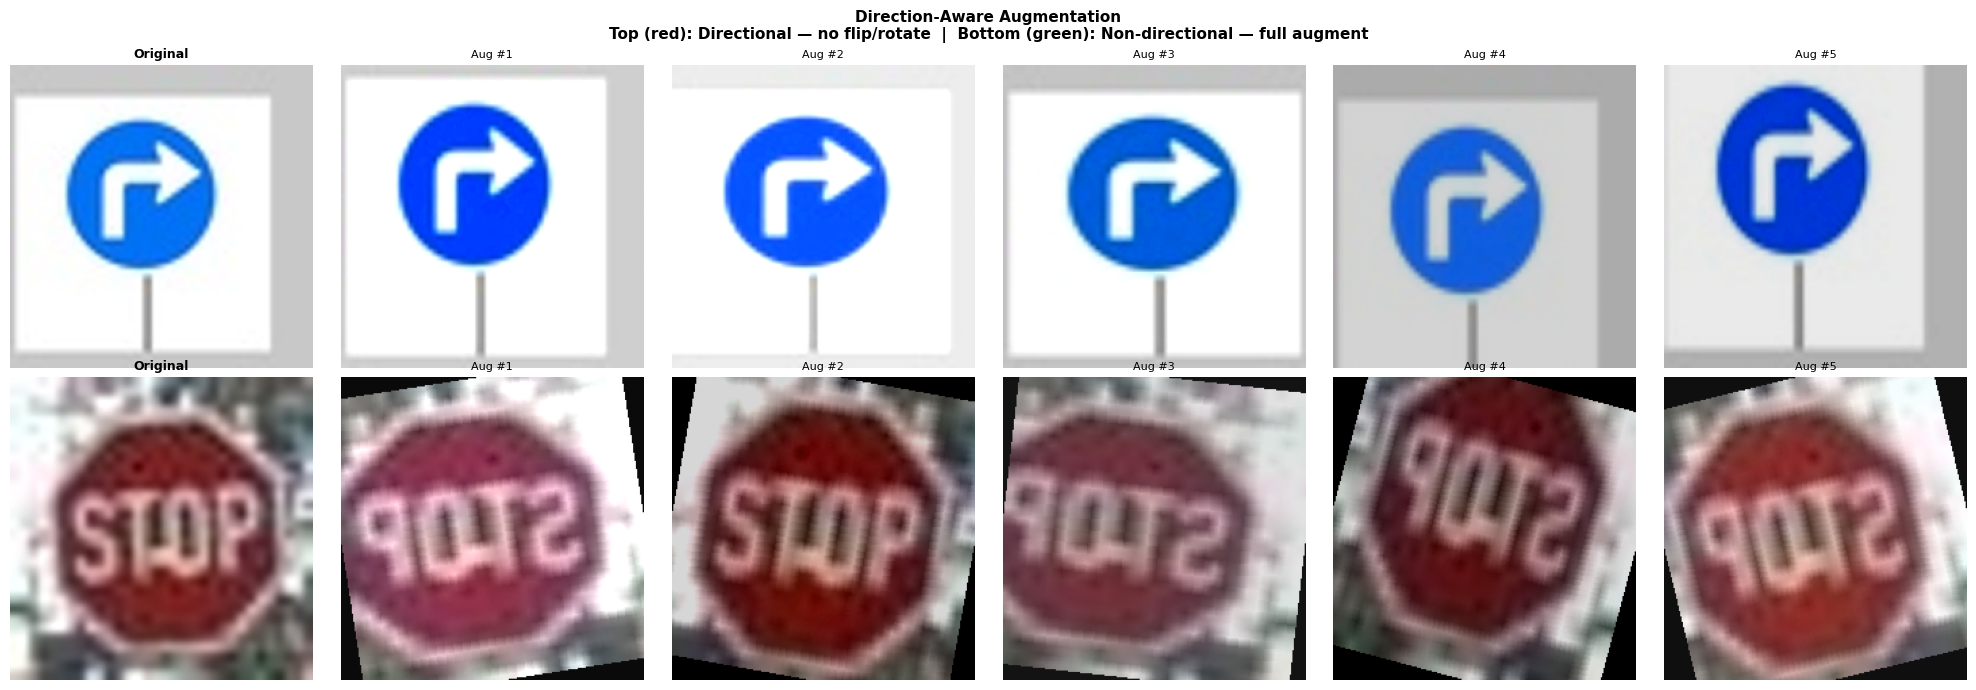

Verify: turnright arrow should ALWAYS point right across all augmented versions.


In [ ]:
# ── VIZ 3: Augmentation visualization
# Show one directional and one non-directional sign
# to confirm direction is preserved

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
fig.suptitle(
    'Direction-Aware Augmentation\n'
    'Directional — no flip/rotate  |  Non-directional — full augment',
    fontsize=11, fontweight='bold'
)

for row_idx, cls in enumerate(['turnright', 'stop']):
    paths_cls = df[df['label'] == cls]['filepath'].tolist()
    lbl_idx   = class_to_idx[cls]
    src_path  = random.choice(paths_cls)
    src_img   = Image.open(src_path).convert('RGB')

    # Original
    axes[row_idx, 0].imshow(src_img.resize((IMG_SIZE, IMG_SIZE)))
    axes[row_idx, 0].set_title('Original', fontsize=9, fontweight='bold')
    axes[row_idx, 0].set_ylabel(
        f'{cls}\n(DIRECTIONAL)' if cls in DIRECTIONAL_CLASSES else f'{cls}\n(non-directional)',
        fontsize=8, color='red' if cls in DIRECTIONAL_CLASSES else 'green'
    )
    axes[row_idx, 0].axis('off')

    # 5 augmented
    transform = train_transform_directional if cls in DIRECTIONAL_CLASSES else train_transform_normal
    for col in range(1, 6):
        aug_tensor = transform(src_img)
        aug_img    = denormalize(aug_tensor).permute(1, 2, 0).numpy()
        axes[row_idx, col].imshow(aug_img)
        axes[row_idx, col].set_title(f'Aug #{col}', fontsize=8)
        axes[row_idx, col].axis('off')

plt.tight_layout()
plt.savefig('/content/viz_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verify: turnright arrow should ALWAYS point right across all augmented versions.')

---
## Step 6: ResNet18 Model Setup (Transfer Learning)

ResNet18 architecture:
```
Input (224×224×3)
  │
Conv7×7, 64 filters, stride 2  →  112×112
MaxPool 3×3, stride 2          →  56×56
  │
Layer1: 2 residual blocks, 64 filters   →  56×56
Layer2: 2 residual blocks, 128 filters  →  28×28
Layer3: 2 residual blocks, 256 filters  →  14×14
Layer4: 2 residual blocks, 512 filters  →  7×7
  │
Global Average Pool  →  512
  │
FC(1000)  ← REPLACED with FC(15) for our task
```

We replace the final FC layer (1000 ImageNet classes → 15 traffic sign classes).

In [ ]:
# ── Load ResNet18 with pre-trained ImageNet weights
# weights='IMAGENET1K_V1' downloads weights trained on 1.2M ImageNet images
# The model already knows: edges, textures, shapes, objects
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

print('ResNet18 loaded with ImageNet weights')
print(f'Original final layer: {model.fc}')
print(f'Original output classes: 1000 (ImageNet)')

# ── Replace the final fully connected layer
# model.fc is the classifier head — originally outputs 1000 classes
# We replace it with a new layer that outputs NUM_CLASSES (15)
# The new layer starts with RANDOM weights — it will be trained
in_features = model.fc.in_features  # 512 for ResNet18
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),                        # regularization
    nn.Linear(in_features, 256),              # intermediate layer
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, NUM_CLASSES)               # final output: 15 classes
)

print(f'\nReplaced final layer: {model.fc}')
print(f'New output classes  : {NUM_CLASSES}')

# Move model to GPU
model = model.to(DEVICE)

# Count parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 158MB/s]


ResNet18 loaded with ImageNet weights
Original final layer: Linear(in_features=512, out_features=1000, bias=True)
Original output classes: 1000 (ImageNet)

Replaced final layer: Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=15, bias=True)
)
New output classes  : 15

Total parameters    : 11,311,695
Trainable parameters: 11,311,695


---
## Step 7: Phase 1 — Feature Extraction (Frozen Backbone) Train classifier head ONLY

Freeze all ResNet18 backbone layers — only train the new classifier head.

**Why Phase 1 first?**  
If we immediately fine-tune with a random classifier head, the large random  
gradients from the head can destroy the carefully learned ImageNet features  
in the backbone. Phase 1 trains the head to a reasonable state first.

In [ ]:
# The backbone does the seeing and thinking, The head makes the final decision.

# ── Freeze all backbone layers
# requires_grad=False means these parameters won't be updated during training
for name, param in model.named_parameters():
    if 'fc' not in name:         # freeze everything except our new fc head
        param.requires_grad = False

frozen     = sum(p.numel() for p in model.parameters() if not p.requires_grad)
trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 1 — Feature Extraction:')
print(f'  Frozen params   : {frozen:,}  (ResNet18 backbone — ImageNet weights preserved)')
print(f'  Trainable params: {trainable:,}  (new classifier head only)')

Phase 1 — Feature Extraction:
  Frozen params   : 11,176,512  (ResNet18 backbone — ImageNet weights preserved)
  Trainable params: 135,183  (new classifier head only)


In [ ]:
# ── Training helper functions

def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Run one complete pass through the training data.
    Returns: average loss, accuracy for this epoch.
    """
    model.train()   # set model to training mode (enables Dropout, BatchNorm updates)
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass — get predictions
        optimizer.zero_grad()          # clear previous gradients
        outputs = model(images)        # shape: (batch, 15)
        loss    = criterion(outputs, labels)  # calculate loss

        # Backward pass — calculate gradients and update weights
        loss.backward()                # backpropagation
        optimizer.step()               # update weights

        # Track metrics
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(f'  Step {batch_idx+1}/{len(loader)} — '
                  f'loss: {loss.item():.4f} — '
                  f'acc: {correct/total:.4f}')

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """
    Evaluate model on validation or test set.
    model.eval() disables Dropout and freezes BatchNorm stats.
    torch.no_grad() skips gradient calculation — faster, uses less memory.
    """
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images  = images.to(device)
            labels  = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / total, correct / total


print('Training functions ready.')

Training functions ready.


In [ ]:
# ── Loss function with class weights
# CrossEntropyLoss = standard loss for multi-class classification in PyTorch
# weight=class_weights penalizes mistakes on rare classes more
criterion = nn.CrossEntropyLoss(weight=class_weights)

# ── Optimizer — only optimizes trainable parameters (classifier head)
# filter(lambda p: p.requires_grad, ...) skips frozen backbone params
optimizer_p1 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=PHASE1_LR
)

# ── Learning rate scheduler
scheduler_p1 = ReduceLROnPlateau(
    optimizer_p1, mode='max', factor=0.3,
    patience=4, min_lr=1e-7
)

# ── Training loop — Phase 1
history_p1 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_p1  = 0.0
BEST_P1_PATH     = f'{MODEL_DIR}/best_phase1.pth'

print(f'Phase 1: Feature Extraction — {PHASE1_EPOCHS} epochs')
print(f'Only training classifier head ({trainable:,} params)\n')

for epoch in range(1, PHASE1_EPOCHS + 1):
    print(f'Epoch {epoch}/{PHASE1_EPOCHS}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_p1, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    history_p1['train_loss'].append(train_loss)
    history_p1['train_acc'].append(train_acc)
    history_p1['val_loss'].append(val_loss)
    history_p1['val_acc'].append(val_acc)

    scheduler_p1.step(val_acc)

    if val_acc > best_val_acc_p1:
        best_val_acc_p1 = val_acc
        torch.save(model.state_dict(), BEST_P1_PATH)
        print(f'  New best! val_acc={val_acc:.4f} — model saved')

    print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}\n')

print(f'Phase 1 complete. Best val accuracy: {best_val_acc_p1:.4f}')              # 25,760 images ÷ 64 per batch = 402.5 → rounds to 401 batches
# The training loop prints progress every 100 steps, This is inside  train_one_epoch function, if (batch_idx + 1) % 100 == 0:

Phase 1: Feature Extraction — 15 epochs
Only training classifier head (135,183 params)

Epoch 1/15
  Step 100/401 — loss: 1.1075 — acc: 0.3995
  Step 200/401 — loss: 1.0788 — acc: 0.4957
  Step 300/401 — loss: 1.2308 — acc: 0.5404
  Step 400/401 — loss: 0.7956 — acc: 0.5720
  New best! val_acc=0.6459 — model saved
  train_loss=1.1486  train_acc=0.5722  val_loss=1.0067  val_acc=0.6459

Epoch 2/15
  Step 100/401 — loss: 0.7136 — acc: 0.6844
  Step 200/401 — loss: 0.6784 — acc: 0.6845
  Step 300/401 — loss: 0.5317 — acc: 0.6927
  Step 400/401 — loss: 0.8157 — acc: 0.6939
  New best! val_acc=0.7067 — model saved
  train_loss=0.7840  train_acc=0.6940  val_loss=0.8416  val_acc=0.7067

Epoch 3/15
  Step 100/401 — loss: 0.7837 — acc: 0.7125
  Step 200/401 — loss: 0.6478 — acc: 0.7118
  Step 300/401 — loss: 0.8163 — acc: 0.7102
  Step 400/401 — loss: 0.6269 — acc: 0.7107
  New best! val_acc=0.7510 — model saved
  train_loss=0.7401  train_acc=0.7107  val_loss=0.7156  val_acc=0.7510

Epoch 4/15
 

 ── Why Two-Phase Training?

At the start, the classifier head weights are RANDOM (knows nothing).
The backbone weights are PRE-TRAINED (learned from 1.2M ImageNet images).

If we train both at once from the beginning:
Random head → very large loss → very large gradients flow backwards
→ backbone weights get overwritten → ImageNet knowledge destroyed
This is called "catastrophic forgetting"

So we train in two phases:

PHASE 1 — Feature Extraction (backbone FROZEN)
Only the classifier head is trained.
Backbone stays unchanged — ImageNet knowledge preserved.
Head learns: "given these 512 features → which of 15 signs is this?"
Goal: get the head to a stable, reasonable state first.

PHASE 2 — Fine-Tuning (backbone + head BOTH trained)
Everything is unfrozen and trained together.
Backbone uses very small LR (0.00001) — careful, small updates only.
Head uses slightly higher LR (0.0001) — continues improving.
Goal: carefully adapt backbone features to traffic signs
without destroying pre-trained ImageNet knowledge.

Result: much better final accuracy than training both from scratch together.

classifier head eka empty ekk (head is filled with random numbers before training, which is why it makes completely wrong predictions at the start of Phase 1.)

backbone eke tmyi resnet wl pretrain weights okkoma include wenne

head ekyi backbone ekyi dekma ek para train krot resnet wl pretrain weights okkoma wens wenw

ekyi head ek mulin train krnne, backbone ek podi learning rate ekk yatathe train krnw

Two Reasons Backbone is Safe in Phase 2
Reason 1 — Very small LR:
Even if gradients are large, the tiny LR means backbone weights only change by a tiny amount each step — not enough to destroy ImageNet knowledge.
Reason 2 — Head is already stable:
Phase 1 trained the head to make reasonable predictions → loss is now small → gradients are small → even less damage to backbone.

---
## Step 8: Phase 2 — Fine-Tuning (Unfrozen Backbone) Train BOTH backbone AND head together

Now unfreeze the entire ResNet18 backbone and train everything  
with a very small learning rate — carefully adapting ImageNet features  
to traffic sign specific patterns.

In [ ]:
# ── Load best Phase 1 weights before unfreezing
model.load_state_dict(torch.load(BEST_P1_PATH))
print('Best Phase 1 weights loaded.')

# ── Unfreeze ALL layers
# Now the backbone will also be updated — but with a tiny LR
for param in model.parameters():
    param.requires_grad = True

total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 — Fine-Tuning:')
print(f'  All {total_trainable:,} parameters now trainable')
print(f'  Learning rate: {PHASE2_LR} (very small — careful updates)')

# ── New optimizer with very small LR
# Small LR prevents destroying pre-trained features
# Use different LR for backbone vs head (optional but better)
optimizer_p2 = optim.Adam([
    {'params': model.fc.parameters(),  'lr': PHASE2_LR * 10},  # head: slightly higher
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n],
     'lr': PHASE2_LR}                                           # backbone: very small
])

scheduler_p2 = ReduceLROnPlateau(
    optimizer_p2, mode='max', factor=0.3,
    patience=5, min_lr=1e-9
)

# ── Early stopping
patience_counter = 0
EARLY_STOP_PATIENCE = 10

history_p2 = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc_p2 = 0.0
BEST_P2_PATH    = f'{MODEL_DIR}/best_phase2.pth'

print(f'\nStarting Phase 2: Fine-Tuning — up to {PHASE2_EPOCHS} epochs\n')

for epoch in range(1, PHASE2_EPOCHS + 1):
    print(f'Epoch {epoch}/{PHASE2_EPOCHS}')

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer_p2, criterion, DEVICE)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion, DEVICE)

    history_p2['train_loss'].append(train_loss)
    history_p2['train_acc'].append(train_acc)
    history_p2['val_loss'].append(val_loss)
    history_p2['val_acc'].append(val_acc)

    scheduler_p2.step(val_acc)

    if val_acc > best_val_acc_p2:
        best_val_acc_p2 = val_acc
        torch.save(model.state_dict(), BEST_P2_PATH)
        patience_counter = 0
        print(f'  New best! val_acc={val_acc:.4f} — model saved')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{EARLY_STOP_PATIENCE})')
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

    print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  '
          f'val_loss={val_loss:.4f}  val_acc={val_acc:.4f}\n')

print(f'Phase 2 complete. Best val accuracy: {best_val_acc_p2:.4f}')
# No improvement (1/10) mean - patience Counter — if it reaches 10/10 without a new best val_acc, training stops automatically. 10 mean patience limit = 10
# the counter reset back to 1 after found a new best.

Best Phase 1 weights loaded.
Phase 2 — Fine-Tuning:
  All 11,311,695 parameters now trainable
  Learning rate: 1e-05 (very small — careful updates)

Starting Phase 2: Fine-Tuning — up to 25 epochs

Epoch 1/25
  Step 100/401 — loss: 0.3942 — acc: 0.8194
  Step 200/401 — loss: 0.1675 — acc: 0.8503
  Step 300/401 — loss: 0.3132 — acc: 0.8685
  Step 400/401 — loss: 0.1741 — acc: 0.8834
  New best! val_acc=0.9460 — model saved
  train_loss=0.2876  train_acc=0.8834  val_loss=0.1646  val_acc=0.9460

Epoch 2/25
  Step 100/401 — loss: 0.3340 — acc: 0.9417
  Step 200/401 — loss: 0.1189 — acc: 0.9430
  Step 300/401 — loss: 0.0807 — acc: 0.9463
  Step 400/401 — loss: 0.1121 — acc: 0.9503
  New best! val_acc=0.9677 — model saved
  train_loss=0.1255  train_acc=0.9503  val_loss=0.1082  val_acc=0.9677

Epoch 3/25
  Step 100/401 — loss: 0.1168 — acc: 0.9658
  Step 200/401 — loss: 0.2128 — acc: 0.9686
  Step 300/401 — loss: 0.0323 — acc: 0.9699
  Step 400/401 — loss: 0.0476 — acc: 0.9717
  New best! val

---
## Step 9: Training Visualizations

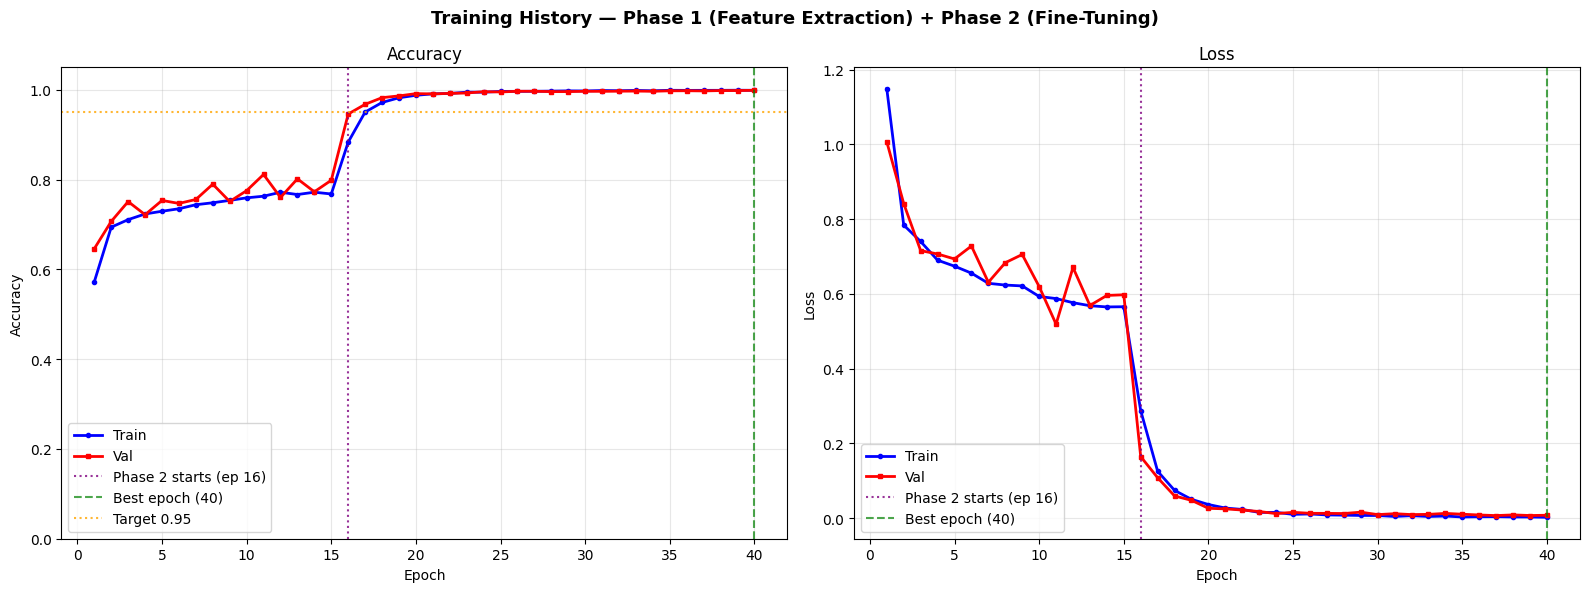

Best val accuracy : 0.9988
Train-Val gap     : -0.0000  (Good fit)


In [ ]:
# ── VIZ 4: Combined Phase 1 + Phase 2 training curves

# Combine both phases for full history
all_train_loss = history_p1['train_loss'] + history_p2['train_loss']
all_val_loss   = history_p1['val_loss']   + history_p2['val_loss']
all_train_acc  = history_p1['train_acc']  + history_p2['train_acc']
all_val_acc    = history_p1['val_acc']    + history_p2['val_acc']

ep_total    = range(1, len(all_train_acc) + 1)
phase2_start = len(history_p1['train_acc']) + 1
best_ep      = np.argmax(all_val_acc) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History — Phase 1 (Feature Extraction) + Phase 2 (Fine-Tuning)',
             fontsize=13, fontweight='bold')

for ax, train_data, val_data, title, ylabel in [
    (axes[0], all_train_acc, all_val_acc, 'Accuracy', 'Accuracy'),
    (axes[1], all_train_loss, all_val_loss, 'Loss', 'Loss')
]:
    ax.plot(ep_total, train_data, 'b-o', ms=3, lw=2, label='Train')
    ax.plot(ep_total, val_data,   'r-s', ms=3, lw=2, label='Val')
    ax.axvline(phase2_start, color='purple', linestyle=':', alpha=0.8,
               label=f'Phase 2 starts (ep {phase2_start})')
    ax.axvline(best_ep, color='green', linestyle='--', alpha=0.7,
               label=f'Best epoch ({best_ep})')
    if title == 'Accuracy':
        ax.axhline(0.95, color='orange', linestyle=':', alpha=0.8, label='Target 0.95')
        ax.set_ylim([0, 1.05])
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/viz_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

gap = all_train_acc[-1] - max(all_val_acc)
print(f'Best val accuracy : {max(all_val_acc):.4f}')
print(f'Train-Val gap     : {gap:.4f}  ({"Good fit" if gap < 0.05 else "Mild overfit" if gap < 0.10 else "Overfit"})')

---
## Step 10: Evaluation on Test Set

In [ ]:
# Load best Phase 2 model weights
model.load_state_dict(torch.load(BEST_P2_PATH))
model.eval()
print('Best model loaded.')

# Evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
if test_acc >= 0.95:
    print('TARGET ACHIEVED: accuracy >= 95%')
else:
    print(f'Gap to target: {(0.95 - test_acc)*100:.2f}%')

Best model loaded.

Test Loss     : 0.0031
Test Accuracy : 0.9994  (99.94%)
TARGET ACHIEVED: accuracy >= 95%


In [ ]:
# ── Collect all predictions
all_preds, all_true, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)   # convert logits to probabilities
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

y_pred = np.array(all_preds)
y_true = np.array(all_true)
y_prob = np.array(all_probs)

print(f'Predictions collected: {len(y_pred)}')

Predictions collected: 3422


                    precision    recall  f1-score   support

          exitleft       1.00      1.00      1.00        30
         exitright       1.00      1.00      1.00       613
           giveway       1.00      1.00      1.00       489
           noentry       1.00      1.00      1.00       368
      noovertaking       1.00      1.00      1.00        77
            oneway       1.00      1.00      1.00       270
        pedestrian       1.00      1.00      1.00       107
        roundabout       1.00      0.99      1.00       121
     speedlimit100       1.00      1.00      1.00       288
      speedlimit20       1.00      1.00      1.00       110
      speedlimit60       1.00      1.00      1.00       306
              stop       1.00      1.00      1.00       262
trafficsignalahead       1.00      1.00      1.00       163
          turnleft       0.99      1.00      1.00       138
         turnright       1.00      1.00      1.00        80

          accuracy                    

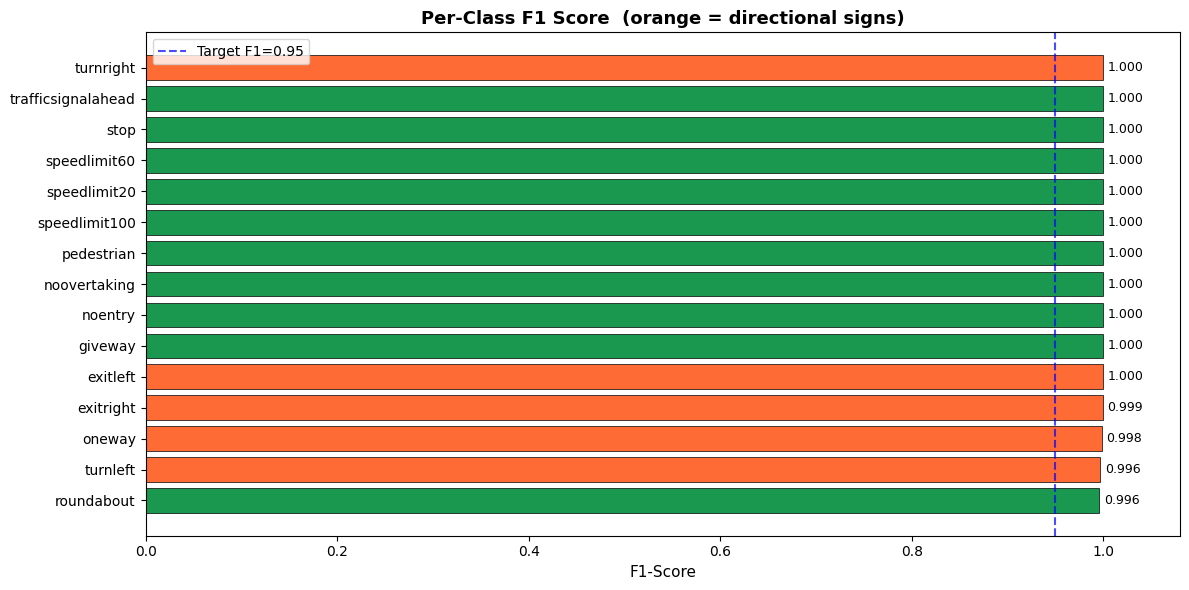

In [ ]:
# ── VIZ 5: Per-class F1 score
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)
f1s    = {cls: report[cls]['f1-score'] for cls in CLASS_NAMES}
f1s    = dict(sorted(f1s.items(), key=lambda x: x[1]))

bar_colors = []
for cls, val in f1s.items():
    if cls in DIRECTIONAL_CLASSES:
        bar_colors.append('#FF6B35')
    elif val < 0.90:
        bar_colors.append('#d73027')
    elif val < 0.95:
        bar_colors.append('#fee090')
    else:
        bar_colors.append('#1a9850')

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(f1s.keys()), list(f1s.values()),
               color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(0.95, color='blue', linestyle='--', alpha=0.7, label='Target F1=0.95')
ax.set_xlabel('F1-Score', fontsize=11)
ax.set_title('Per-Class F1 Score  (orange = directional signs)',
             fontsize=13, fontweight='bold')
ax.set_xlim([0, 1.08]); ax.legend()
for bar, val in zip(bars, f1s.values()):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/content/viz_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

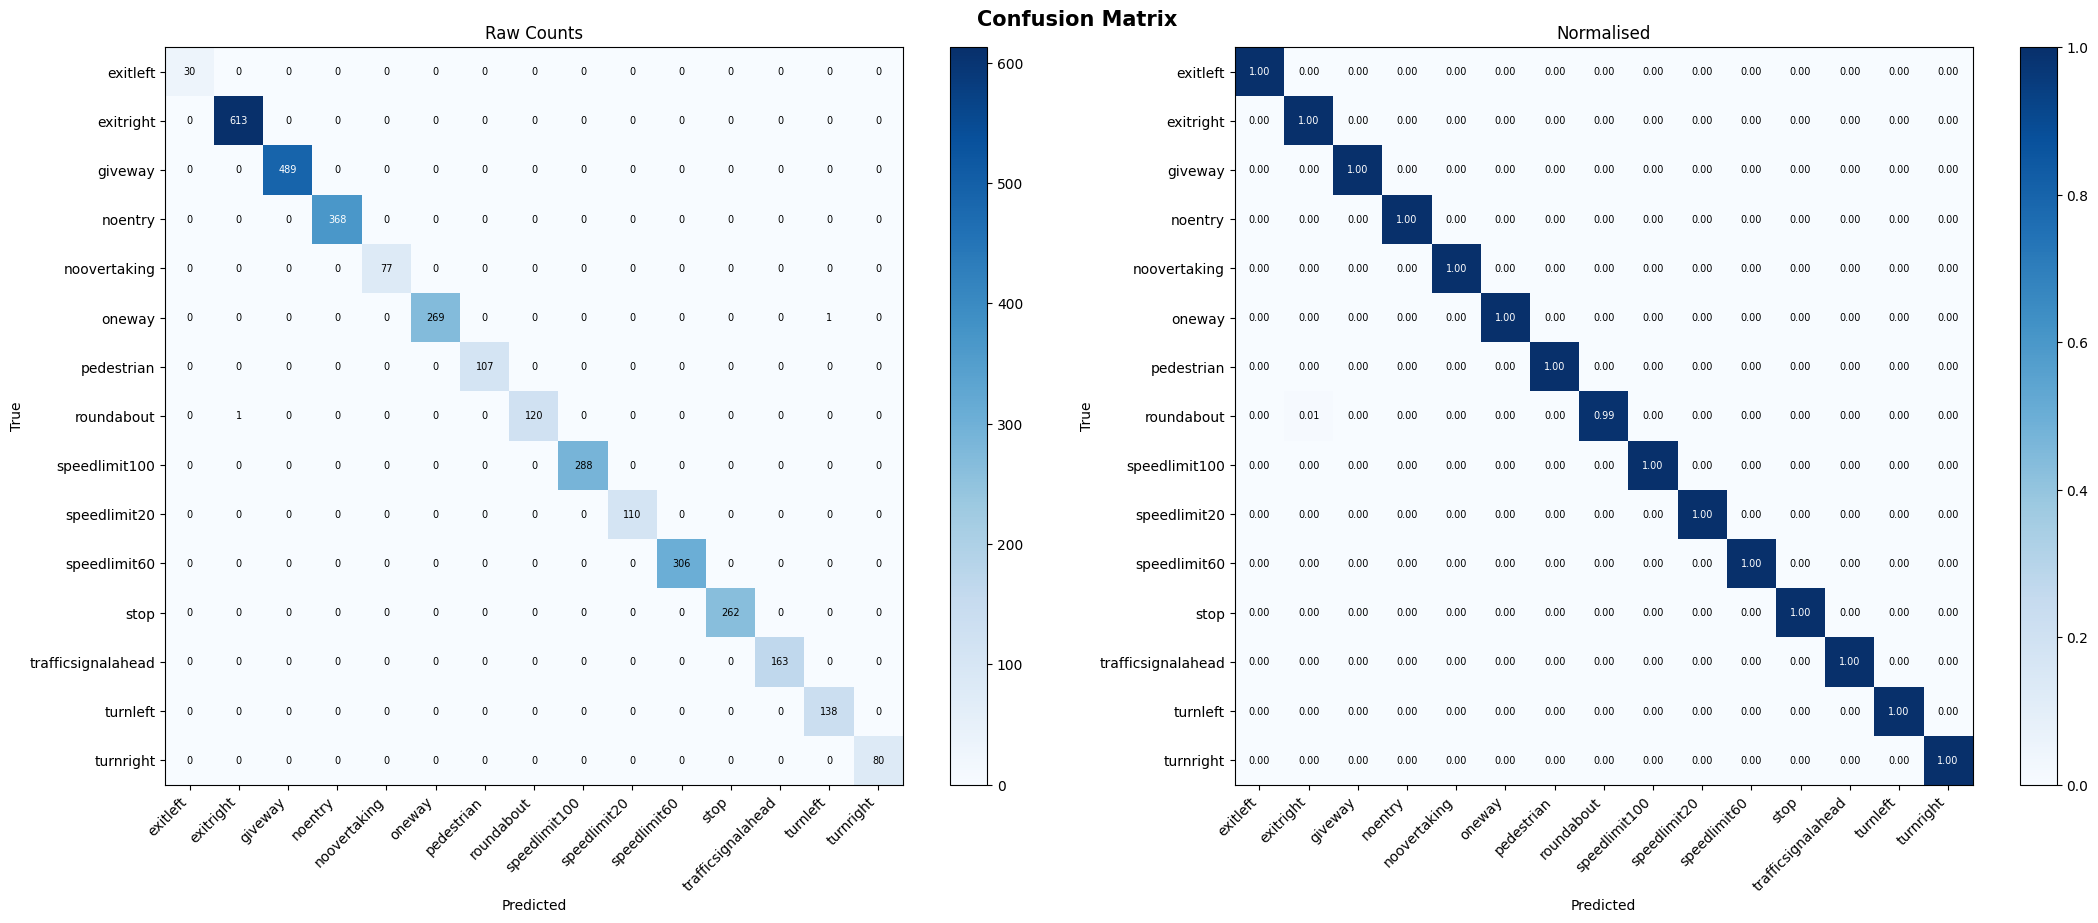

Directional sign confusion check (should be near 0):
  turnleft predicted as turnright: 0 times
  turnright predicted as turnleft: 0 times
  exitleft predicted as exitright: 0 times
  exitright predicted as exitleft: 0 times


In [ ]:
# ── VIZ 6: Confusion matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle('Confusion Matrix', fontsize=15, fontweight='bold')

for ax, data, title in [
    (axes[0], cm, 'Raw Counts'),
    (axes[1], cm_norm, 'Normalised')
]:
    im = ax.imshow(data, cmap='Blues',
                   vmin=0, vmax=(1 if 'Norm' in title else None))
    plt.colorbar(im, ax=ax)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_title(title)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = data[i, j]
            txt = f'{val:.2f}' if 'Norm' in title else str(int(val))
            color = 'white' if val > (0.5 if 'Norm' in title else data.max()/2) else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=7, color=color)

plt.tight_layout()
plt.savefig('/content/viz_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Directional confusion check
print('Directional sign confusion check (should be near 0):')
for cls_a, cls_b in [('turnleft','turnright'), ('exitleft','exitright')]:
    if cls_a in class_to_idx and cls_b in class_to_idx:
        i, j = class_to_idx[cls_a], class_to_idx[cls_b]
        print(f'  {cls_a} predicted as {cls_b}: {cm[i,j]} times')
        print(f'  {cls_b} predicted as {cls_a}: {cm[j,i]} times')

Wrong: 2 / 3422  (0.1%)


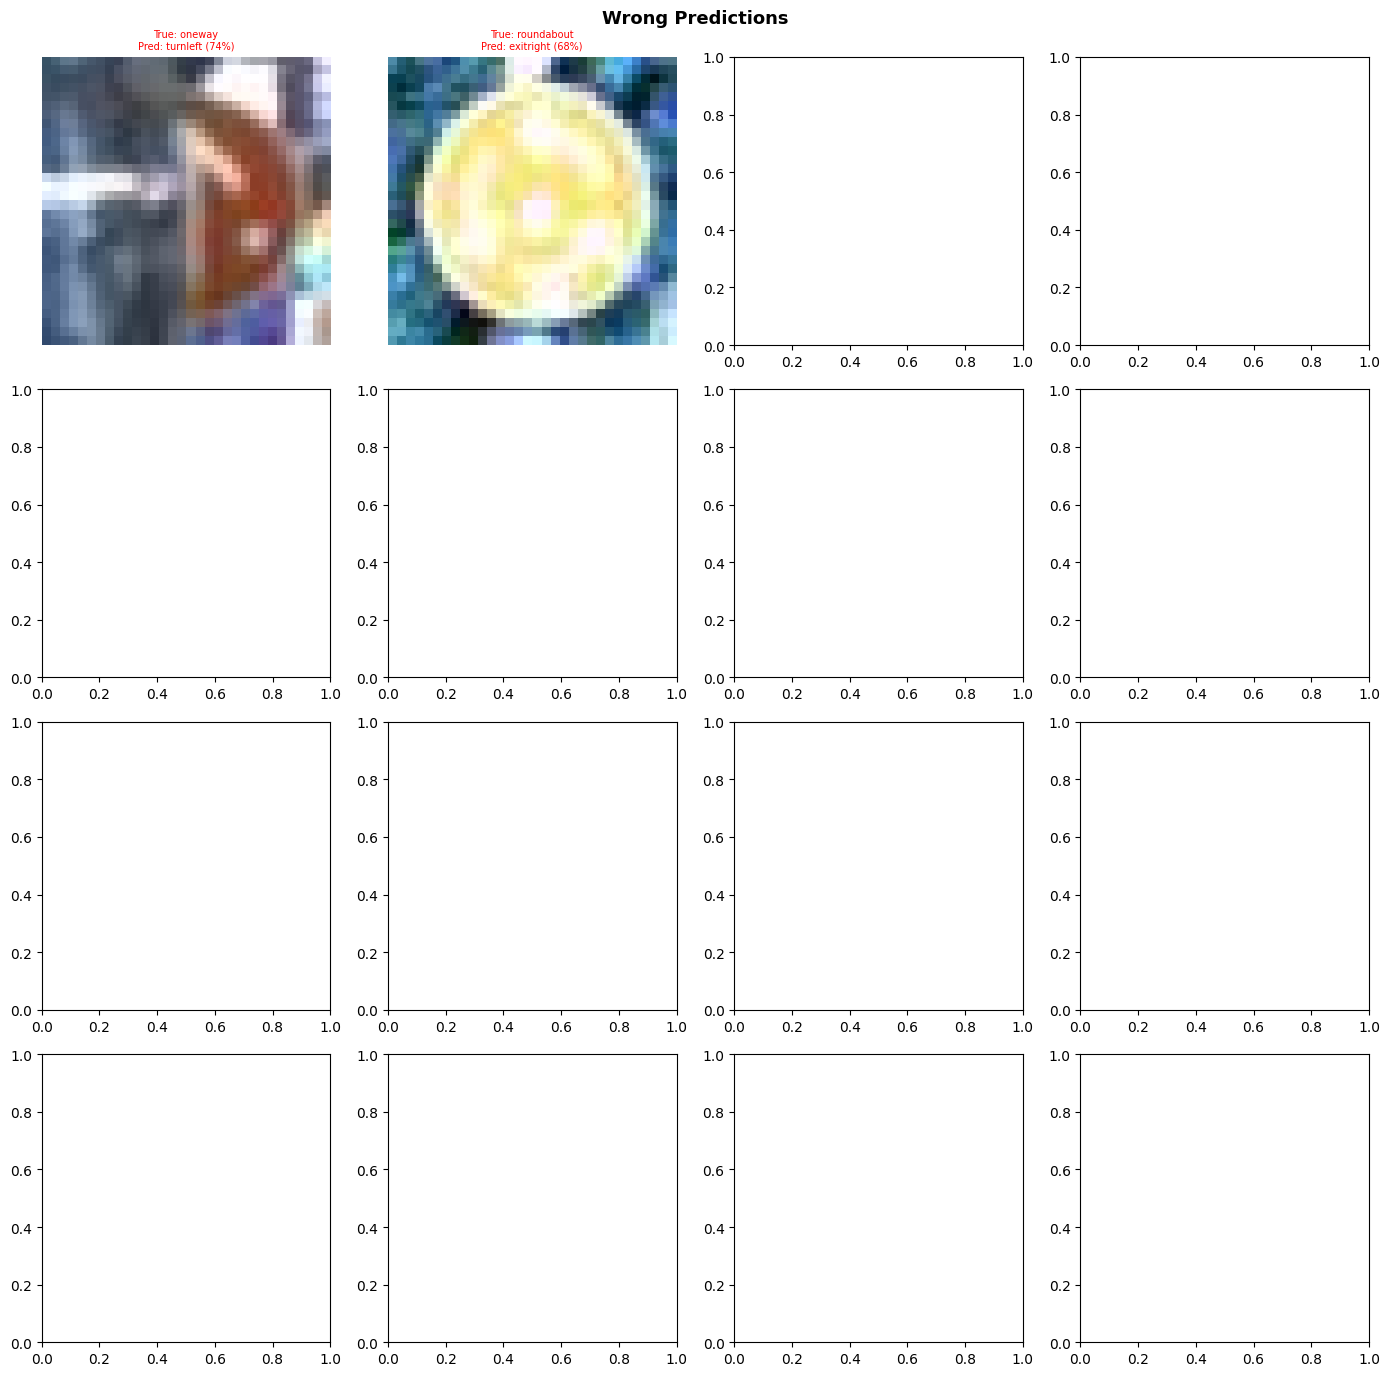

In [ ]:
# ── VIZ 7: Wrong predictions
wrong_idxs = np.where(y_pred != y_true)[0]
print(f'Wrong: {len(wrong_idxs)} / {len(y_true)}  ({len(wrong_idxs)/len(y_true)*100:.1f}%)')

if len(wrong_idxs) > 0:
    picks = random.sample(list(wrong_idxs), min(16, len(wrong_idxs)))
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle('Wrong Predictions', fontsize=13, fontweight='bold')
    for ax, idx in zip(axes.flatten(), picks):
        ax.imshow(Image.open(test_paths[idx]).convert('RGB'))
        ax.set_title(
            f'True: {CLASS_NAMES[y_true[idx]]}\n'
            f'Pred: {CLASS_NAMES[y_pred[idx]]} ({y_prob[idx][y_pred[idx]]:.0%})',
            fontsize=7, color='red'
        )
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/viz_wrong_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Step 11: Prediction Demo

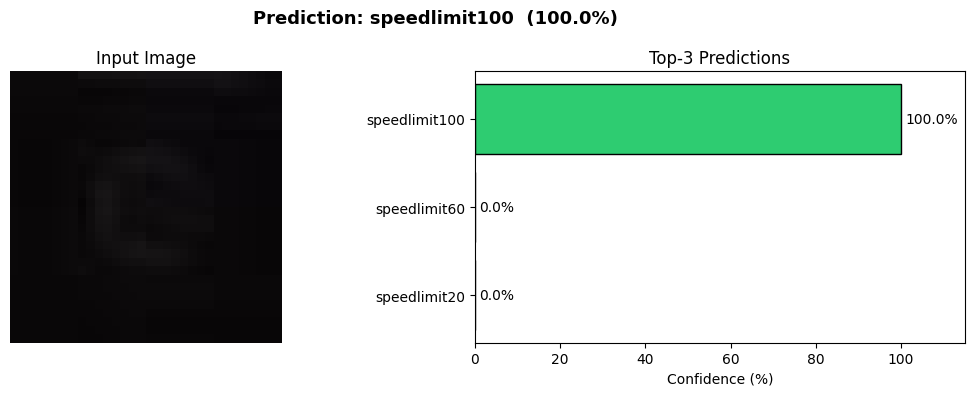

[1] True: speedlimit100         Pred: speedlimit100         CORRECT


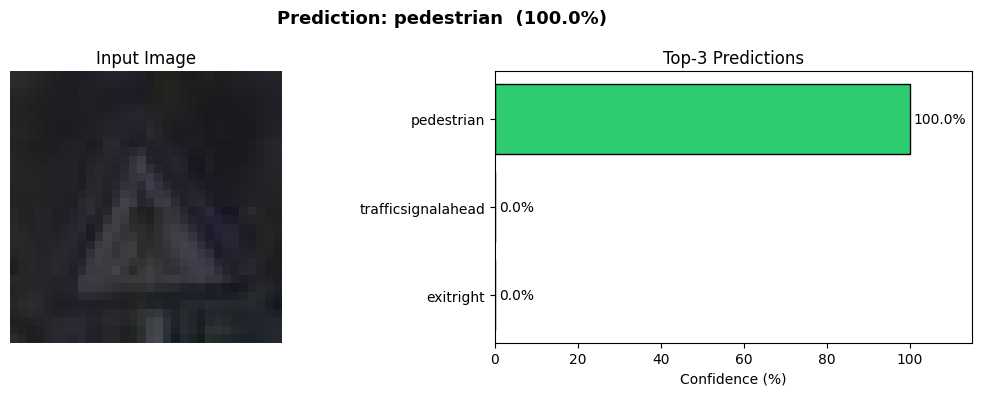

[2] True: pedestrian            Pred: pedestrian            CORRECT


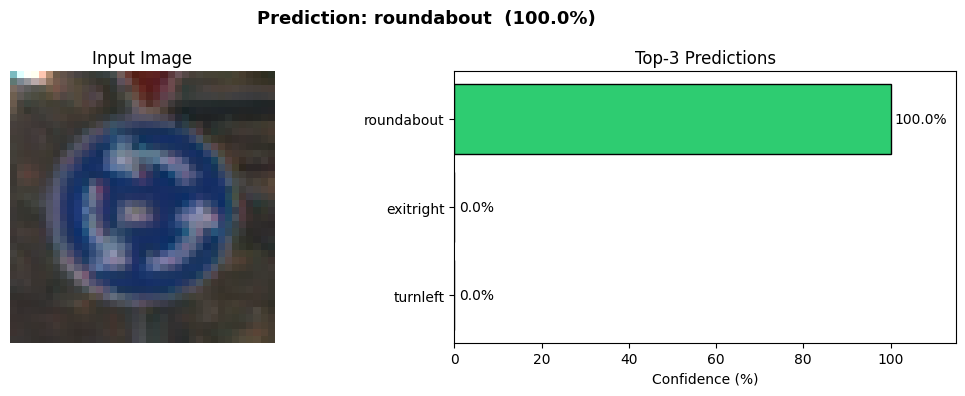

[3] True: roundabout            Pred: roundabout            CORRECT


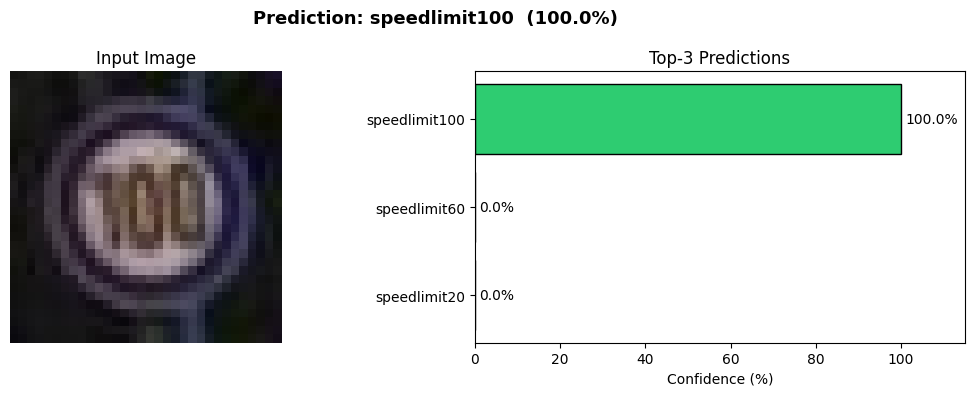

[4] True: speedlimit100         Pred: speedlimit100         CORRECT


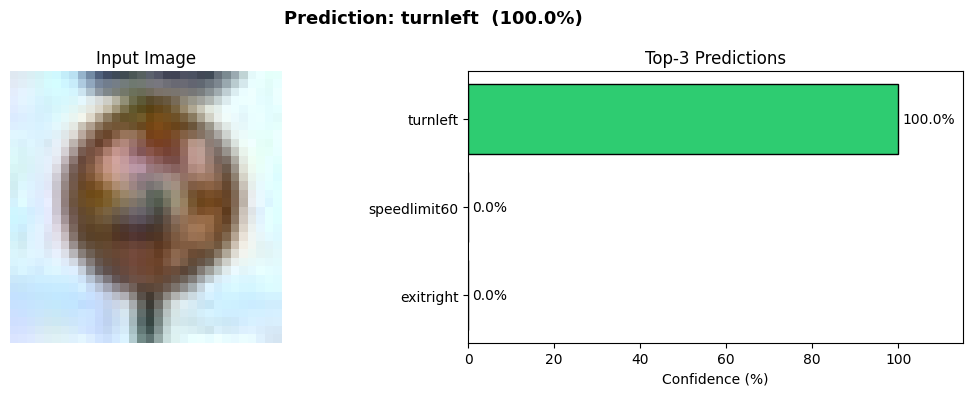

[5] True: turnleft              Pred: turnleft              CORRECT


In [ ]:
def predict_single(model, image_path, class_names, transform, device):
    """Load one image, run the model, show top-3 predictions."""
    img    = Image.open(image_path).convert('RGB')
    tensor = transform(img).unsqueeze(0).to(device)  # (1, 3, 224, 224)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0].cpu().numpy()

    top3       = np.argsort(probs)[::-1][:3]
    t_labels   = [class_names[i] for i in top3]
    t_confs    = [probs[i] * 100 for i in top3]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(img); axes[0].axis('off'); axes[0].set_title('Input Image')

    colors = ['#2ecc71', '#95a5a6', '#95a5a6']
    axes[1].barh(t_labels[::-1], t_confs[::-1], color=colors[::-1], edgecolor='black')
    axes[1].set_xlabel('Confidence (%)'); axes[1].set_title('Top-3 Predictions')
    axes[1].set_xlim([0, 115])
    for i, v in enumerate(t_confs[::-1]):
        axes[1].text(v + 1, i, f'{v:.1f}%', va='center', fontsize=10)

    plt.suptitle(f'Prediction: {t_labels[0]}  ({t_confs[0]:.1f}%)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    return t_labels[0]


# Run on 5 random test images
for i, idx in enumerate(random.sample(range(len(test_paths)), 5)):
    true_cls = CLASS_NAMES[y_true[idx]]
    pred_cls = predict_single(model, test_paths[idx], CLASS_NAMES,
                               val_test_transform, DEVICE)
    result   = 'CORRECT' if pred_cls == true_cls else 'WRONG'
    print(f'[{i+1}] True: {true_cls:<20}  Pred: {pred_cls:<20}  {result}')

---
## Step 12: Save & Download Model

In [ ]:
# ── Save full model (architecture + weights)
FINAL_MODEL_PATH = f'{MODEL_DIR}/resnet18_traffic_signs.pth'
torch.save({
    'model_state_dict'  : model.state_dict(),
    'class_names'       : CLASS_NAMES,
    'class_to_idx'      : class_to_idx,
    'num_classes'       : NUM_CLASSES,
    'img_size'          : IMG_SIZE,
    'imagenet_mean'     : IMAGENET_MEAN,
    'imagenet_std'      : IMAGENET_STD,
    'phase1_best_acc'   : best_val_acc_p1,
    'phase2_best_acc'   : best_val_acc_p2,
    'test_accuracy'     : test_acc,
}, FINAL_MODEL_PATH)

# Save class names JSON
with open(f'{MODEL_DIR}/class_names.json', 'w') as f:
    json.dump({'classes': CLASS_NAMES, 'class_to_idx': class_to_idx}, f, indent=2)

# Save training history
history_combined = {
    'train_acc' : all_train_acc,
    'val_acc'   : all_val_acc,
    'train_loss' : all_train_loss,
    'val_loss'   : all_val_loss,
}
pd.DataFrame(history_combined).to_csv(f'{MODEL_DIR}/training_history.csv', index=False)

print('Files saved:')
for p in Path(MODEL_DIR).iterdir():
    size = p.stat().st_size / (1024*1024)
    print(f'  {p.name:<40} {size:.1f} MB')

print(f'\nFinal Test Accuracy  : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Phase 1 Best Val Acc : {best_val_acc_p1:.4f}')
print(f'Phase 2 Best Val Acc : {best_val_acc_p2:.4f}')

Files saved:
  class_names.json                         0.0 MB
  best_phase2.pth                          43.2 MB
  training_history.csv                     0.0 MB
  resnet18_traffic_signs.pth               43.2 MB
  best_phase1.pth                          43.2 MB

Final Test Accuracy  : 0.9994  (99.94%)
Phase 1 Best Val Acc : 0.8114
Phase 2 Best Val Acc : 0.9988


In [ ]:
# Download to your computer
from google.colab import files
files.download(FINAL_MODEL_PATH)
files.download(f'{MODEL_DIR}/class_names.json')
print('Downloading model and class names...')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## How to Load This Model for Inference

```python
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms
from PIL import Image

# Load checkpoint
checkpoint = torch.load('resnet18_traffic_signs.pth', map_location='cpu')

# Rebuild model architecture
model = models.resnet18(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, checkpoint['num_classes'])
)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Preprocess image
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=checkpoint['imagenet_mean'],
                         std=checkpoint['imagenet_std'])
])

# Predict
img    = Image.open('sign.jpg').convert('RGB')
tensor = transform(img).unsqueeze(0)
with torch.no_grad():
    probs  = torch.softmax(model(tensor), dim=1)[0]
    pred   = probs.argmax().item()
    print(checkpoint['class_names'][pred], f'{probs[pred]*100:.1f}%')
```

